#### Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.utils import to_categorical

#### Load MNIST Data

In [ ]:
# Load dataset from python data lab
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Check the shape
print(X_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

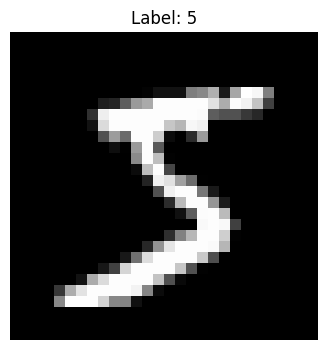

In [ ]:
# Visualise sample images
plt.figure(figsize=(4, 4))
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")


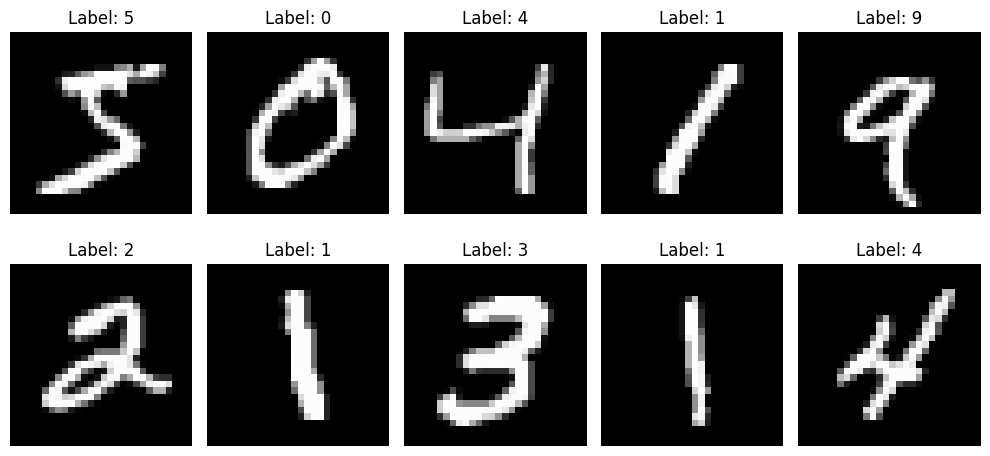

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(X_train[i], cmap="gray")
  plt.title(f"Label: {y_train[i]}")
  plt.axis("off")

plt.tight_layout()
plt.show()

Preprocessing

In [ ]:
# Normalisation
X_train = X_train / 255.0
X_test = X_test / 255.0

# Do one-hot encoding on labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

Build the Neural Network

In [9]:
# Build NN
model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

Compile

In [10]:
# Configure the model for training
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Train the Model

In [12]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9193 - loss: 0.2852 - val_accuracy: 0.9552 - val_loss: 0.1546
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9624 - loss: 0.1264 - val_accuracy: 0.9685 - val_loss: 0.1104
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9753 - loss: 0.0849 - val_accuracy: 0.9712 - val_loss: 0.1000
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9805 - loss: 0.0638 - val_accuracy: 0.9735 - val_loss: 0.0892
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9847 - loss: 0.0489 - val_accuracy: 0.9719 - val_loss: 0.0928
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9883 - loss: 0.0380 - val_accuracy: 0.9750 - val_loss: 0.0823
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9905 - loss: 0.0298 - val_accuracy: 0.9751 - val_loss: 0.0832
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9929 - loss: 0.0234 - 

Evaluating the Model

In [18]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9758 - loss: 0.0891
Test Accuracy: 0.9757999777793884


#### Make Prediction

In [19]:
predictions = model.predict(X_test)

predicted_digit = np.argmax(predictions[1])
true_digit = np.argmax(y_test[1])

print(f"Predicted: {predicted_digit}")
print(f"Actual: {true_digit}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted: 2
Actual: 2


#### Save the Model

In [20]:
# Save the model
model.save('mnist_model.keras')
print(f"Model saved as 'mnist_model.keras'")

# Download
from google.colab import files
files.download('mnist_model.keras')
print(f"Model downloaded sucessfully to my computer!")

Model saved as 'mnist_model.keras'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model downloaded sucessfully to my computer!
